## **This is my submission to the Housing Prices Competition for Kaggle Learn Users.**

### Importing libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split

### Read data

In [2]:
train=pd.read_csv('../input/home-data-for-ml-course/train.csv', index_col='Id')
test=pd.read_csv('../input/home-data-for-ml-course/test.csv', index_col='Id')

### Data Analysis -Train Data

In [3]:
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [5]:
#for analysing MSzoning column
#find the unique values in MSZoning column
train['MSZoning'].unique()

array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object)

<AxesSubplot:xlabel='MSZoning', ylabel='count'>

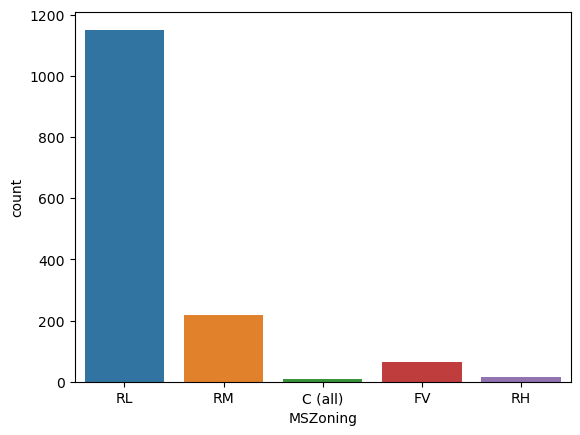

In [6]:
#countplot
sns.countplot(x='MSZoning',data=train)

<AxesSubplot:xlabel='SaleCondition', ylabel='count'>

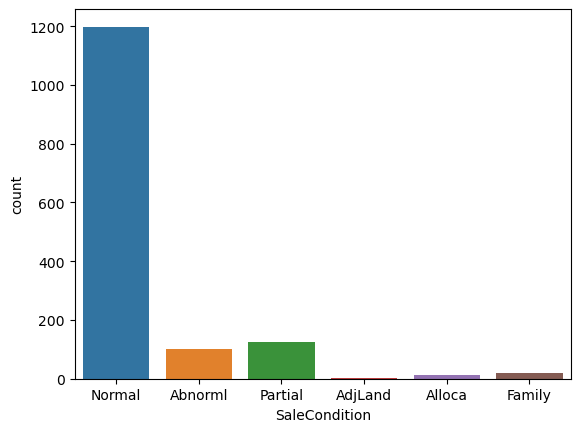

In [7]:
#analysing SaleCondition column
#countplot
sns.countplot(x='SaleCondition',data=train)

In [8]:
#checking columns with null values
train_col_null=train.columns[train.isnull().any()==True].tolist()
train[train_col_null].isnull().sum()

LotFrontage      259
Alley           1369
MasVnrType         8
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

### Data Analysis - Test Data

In [9]:
test.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [10]:
test.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

<AxesSubplot:xlabel='MSZoning', ylabel='count'>

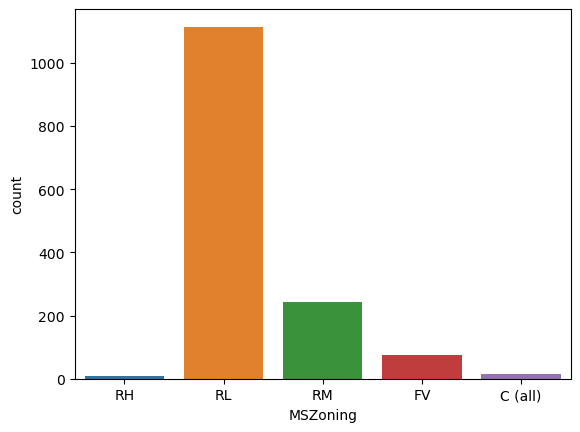

In [11]:
#countplot
sns.countplot(x='MSZoning',data=test)

<AxesSubplot:xlabel='SaleCondition', ylabel='count'>

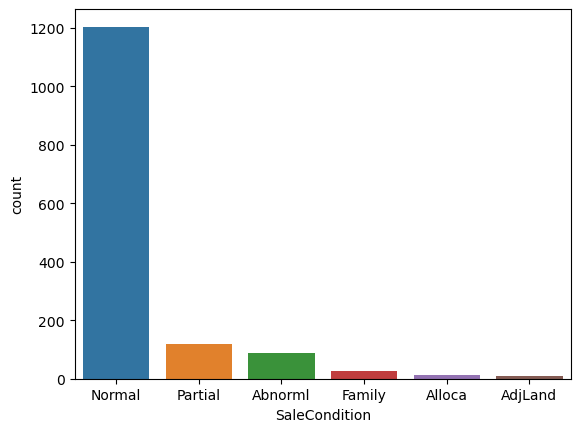

In [12]:
#countplot
sns.countplot(x='SaleCondition',data=test)

In [13]:
#checking columns with null values
test_col_null=test.columns[test.isnull().any()==True].tolist()
test[test_col_null].isnull().sum()

MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType        16
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageYrBlt       78
GarageFinish      78
GarageCars         1
GarageArea         1
GarageQual        78
GarageCond        78
PoolQC          1456
Fence           1169
MiscFeature     1408
SaleType           1
dtype: int64

### **Feature Engineering**

In [14]:
#Remove row with missing target
X=train.dropna(axis=0,subset=['SalePrice'])

In [15]:
#seperate target from predictors
y=X.SalePrice
X.drop(['SalePrice'],axis=1,inplace=True)

In [16]:
#break off validation set from training data
X_train_full,X_valid_full,y_train,y_valid=train_test_split(X,y,train_size=0.8,test_size=0.2,random_state=0)

In [17]:
#to find the no of inique values in the column 
#select categorical columns with relatively low cardinality(number of unique value)
low_cardinality_col=[n for n in X_train_full.columns if X_train_full[n].nunique()<10 and X_train_full[n].dtype=='object']

In [18]:
#select numeric columns
numeric_col=[i for i in X_train_full.columns if X_train_full[i].dtype in ['int64','float64']]

In [19]:
#keep selected columns only
my_col=low_cardinality_col+numeric_col

X_train=X_train_full[my_col].copy()
X_valid=X_valid_full[my_col].copy()

#for test data
X_test=test[my_col].copy()

In [20]:
#one_hot encode the data
X_train=pd.get_dummies(X_train)
X_valid=pd.get_dummies(X_valid)
X_test=pd.get_dummies(X_test)

X_train,X_valid=X_train.align(X_valid,join='left',axis=1)
X_train,X_test=X_train.align(X_test,join='left',axis=1)

### **Model Fitting and prediction**

In [21]:
from xgboost import XGBRegressor

xgb=XGBRegressor(n_estimato=1000,learning_rate=0.05)

In [22]:
#fit the model
xgb.fit(X_train,y_train)

[05:20:42] WARNING: ../src/learner.cc:627: 
Parameters: { "n_estimato" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.05, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimato=1000,
             n_estimators=100, n_jobs=0, num_parallel_tree=1, predictor='auto',
             random_state=0, reg_alpha=0, ...)

In [23]:
#get predictions
y_predi=xgb.predict(X_valid)

In [24]:
#to calculate mean absolute error MAE

from sklearn.metrics import mean_absolute_error

mae=mean_absolute_error(y_predi,y_valid)
print('MAE : ',mae)

MAE :  17213.82253317637


In [25]:
#prediction
prediction=xgb.predict(X_test)

### **Submission file**

In [26]:
output=pd.DataFrame({'id':X_test.index,'SalePrice':prediction})
output.to_csv('submision.csv',index=False)

In [27]:
output.head()

,id,SalePrice
0,1461,123748.296875
1,1462,150485.984375
2,1463,187303.265625
3,1464,185940.062500
4,1465,198316.406250
